In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

In [2]:
data=pd.read_csv("train.csv")
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
X=data.drop(columns=["Id","SalePrice"])
y=data["SalePrice"]

y = np.log1p(y)

In [4]:
X = pd.get_dummies(X, drop_first=True)

In [5]:
X["LotFrontage"] = X["LotFrontage"].fillna(X["LotFrontage"].median())
X["GarageYrBlt"] = X["GarageYrBlt"].fillna(X["GarageYrBlt"].median())
X["MasVnrArea"] = X["MasVnrArea"].fillna(X["MasVnrArea"].median())

In [6]:
# create a copy
X_original = X.copy()

In [7]:
#remove highly correlated features
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression

selector = SelectKBest(score_func=f_regression, k=50)

X_new = selector.fit_transform(X, y)

selected_columns = X.columns[selector.get_support()]

X = pd.DataFrame(X_new, columns=selected_columns)

In [8]:
X["TotalSF"] = X["TotalBsmtSF"] + X["1stFlrSF"] + X["2ndFlrSF"]

X["TotalBathrooms"] = X["FullBath"] + 0.5 * X["HalfBath"]

X["TotalPorch"] = X["WoodDeckSF"] + X["OpenPorchSF"]

X["QualityArea"] = X["OverallQual"] * X["GrLivArea"]

In [9]:
# train test split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42)

In [10]:
#train model
model=LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
y_pred=model.predict(X_test)

In [12]:
r2=r2_score(y_test,y_pred)
print("R2 Score: ",r2)

n=X_test.shape[0]    # rows
p=X_test.shape[1]  # features --- no of columns
adjusted_r2= 1- ((1-r2) * (n-1) / (n-p-1))
print("Adjusted R2 value: ",adjusted_r2)

R2 Score:  0.8728255585699329
Adjusted R2 value:  0.8438491035605505


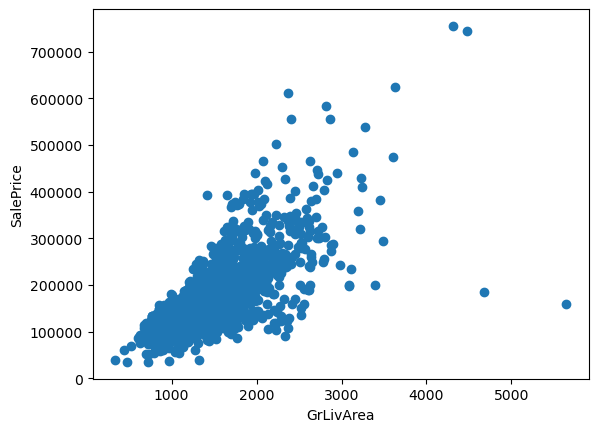

In [13]:
import matplotlib.pyplot as plt

plt.scatter(data["GrLivArea"], data["SalePrice"])
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.show()

In [14]:
X.columns

Index(['LotFrontage', 'OverallQual', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea',
       'BsmtFinSF1', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea',
       'FullBath', 'HalfBath', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt',
       'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'MSZoning_RL',
       'MSZoning_RM', 'LotShape_Reg', 'Neighborhood_NoRidge',
       'Neighborhood_NridgHt', 'HouseStyle_2Story', 'Exterior1st_VinylSd',
       'Exterior2nd_VinylSd', 'MasVnrType_Stone', 'ExterQual_Gd',
       'ExterQual_TA', 'Foundation_CBlock', 'Foundation_PConc', 'BsmtQual_Gd',
       'BsmtQual_TA', 'BsmtExposure_Gd', 'BsmtFinType1_GLQ', 'HeatingQC_TA',
       'CentralAir_Y', 'Electrical_SBrkr', 'KitchenQual_Gd', 'KitchenQual_TA',
       'FireplaceQu_Gd', 'GarageType_Attchd', 'GarageType_Detchd',
       'GarageFinish_Unf', 'GarageQual_TA', 'GarageCond_TA', 'PavedDrive_Y',
       'SaleType_New', 'SaleCondition_Partial', 'TotalSF', 'TotalBathrooms',
       'TotalPorch', 'QualityArea